## Aim

In this code, I do a few checks before writing the actual programs:

- I want to read a network and then save it for later use
- See if it is possible once I have the bigger network and when I have save it to extract networks bases on the wards. This avoids that one has to hit the Overpass server multiple times in case one would download the network for each ward seperately (369 wards in total).
- Compute the following metrics (on one ward only)
- 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
print(f'The version of geopandas is {gpd.__version__}')
print(f'The version of osmnx is {ox.__version__}')

The version of geopandas is 1.1.2
The version of osmnx is 2.0.7


## Reading and saving the Bangalore network

In [3]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [4]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [5]:
## Dissolved wards
df_inpath_dissolved = PROCESSED_DIR / "bangalore_dissolved.shp"

In [6]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [7]:
print(f'The shape of the Geopandas dataframe is {df.shape}.')
print(f'There are {df.shape[0]} wards in the dataframe.')
print(f'The different columns are {df.columns}')

The shape of the Geopandas dataframe is (369, 4).
There are 369 wards in the dataframe.
The different columns are Index(['ward_id', 'ward_name', 'Corporatio', 'geometry'], dtype='object')


Although the wards data are cleaned up in QGIS and Mapshaper, we check once more for the validity using Geopandas:

In [8]:
df.geometry.is_valid.value_counts()

True    369
Name: count, dtype: int64

In [9]:
print(f'There are {df.shape[0]} wards in Bangalore.')

There are 369 wards in Bangalore.


## Extracting the road network data

<Axes: >

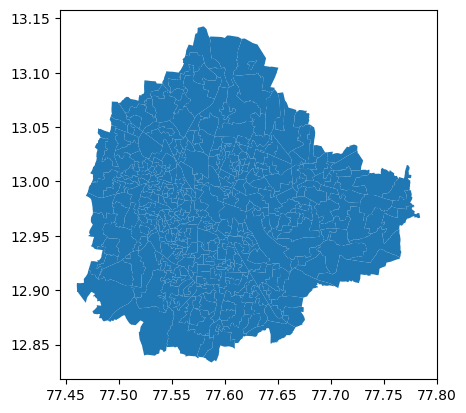

In [10]:
df.plot()

In [11]:
bangalore_dissolved = df.dissolve()

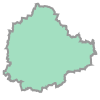

In [12]:
geometry_bang = bangalore_dissolved["geometry"].iloc[0]
geometry_bang

This downloads all the streets. More specifically this consists of: a) 

In [13]:
G = ox.graph_from_polygon(
    geometry_bang,
    simplify=True,
    network_type = 'drive')

In [20]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [15]:
## Save the network for later use as a) graph and b) geopandas dataframe
## https://github.com/gboeing/osmnx-examples/blob/main/notebooks/
## 05-save-load-networks.ipynb
path_gpkg_bang = DATA_DIR / "gpkg_bang" / "bangalore_gpkg_drive.gpkg"

ox.io.save_graph_geopackage(G, filepath=path_gpkg_bang)

A small part of this network will be visualised below. Alternatively, you can upload the file in QGIS. You should see 2 layers. One for the nodes and another one for the edges.

In [16]:
# Save as a network
path_graphml_bang = DATA_DIR / "graphml_bang" / "bangalore_graphml_drive.graphml"
ox.io.save_graphml(G, filepath = path_graphml_bang)

Loading this again (we will  not do that here right now but you can do that at any point in your code and uncomment this line) but you can load the Geopackage like any other loading any regular .gpkg file in Python using Geopandas. The Geopandas file contains two layers. It is best to specify which layer to use in order to avoid warnings. 

In [17]:
## gpkg_test_edges = gpd.read_file(path_gpkg_bang, layer = 'edges')
## gpkg_test_edges.head()

In [18]:
## gpkg_test_edges.columns

In [19]:
gpkg_test_nodes = gpd.read_file(path_gpkg_bang, layer = 'nodes')
gpkg_test_nodes.head()

,osmid,y,x,street_count,highway,junction,ref,geometry
0,17327095,12.910542,77.598721,4,,,,POINT (77.59872 12.91054)
1,17327139,12.934965,77.624072,3,,,,POINT (77.62407 12.93497)
2,17327141,12.938493,77.629168,3,,,,POINT (77.62917 12.93849)
3,17327420,13.095224,77.594178,3,traffic_signals,,,POINT (77.59418 13.09522)
4,17327433,12.985951,77.579325,3,,,,POINT (77.57932 12.98595)


## Visualisation

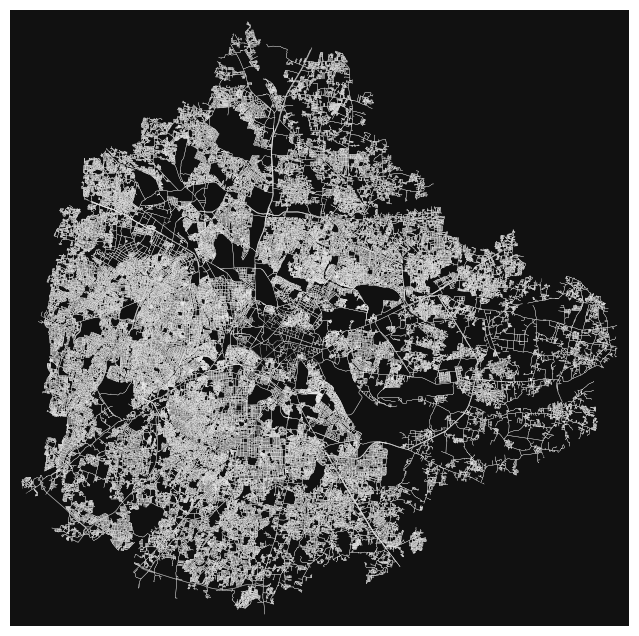

In [20]:
# osmnx built-in plotting
# You can change the basic settings but this here are the default settings
fig, ax = ox.plot_graph(G, node_size=0, edge_color="w", edge_linewidth=0.2)

Convert the graph you loaded in into a Geopandas dataframe. The files that you saved above can also be loaded in otherwise. 

We can convert the graph to a Geopandas dataframe (as this may be easier to work with especially if you want to overlay this with other datasets). 

In [21]:
# nodes, edges = ox.graph_to_gdfs(G)
nodes, edges = ox.graph_to_gdfs(G)
nodes.head()

,y,x,street_count,highway,junction,ref,geometry
osmid,,,,,,,
17327095,12.910542,77.598721,4,NaN,NaN,NaN,POINT (77.59872 12.91054)
17327139,12.934965,77.624072,3,NaN,NaN,NaN,POINT (77.62407 12.93497)
17327141,12.938493,77.629168,3,NaN,NaN,NaN,POINT (77.62917 12.93849)
17327420,13.095224,77.594178,3,traffic_signals,NaN,NaN,POINT (77.59418 13.09522)
17327433,12.985951,77.579325,3,NaN,NaN,NaN,POINT (77.57932 12.98595)


In [22]:
print(f'It is {edges.crs == df.crs} that the coordinate system of the shape file of the wards and the street network are the same.')
print(f'The coordinate system is {df.crs}')

It is True that the coordinate system of the shape file of the wards and the street network are the same.
The coordinate system is EPSG:4326


<Axes: >

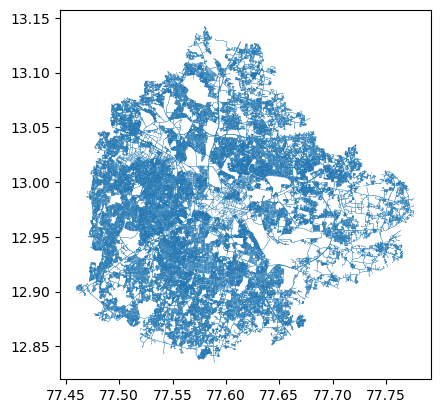

In [23]:
edges.plot(linewidth=0.2)

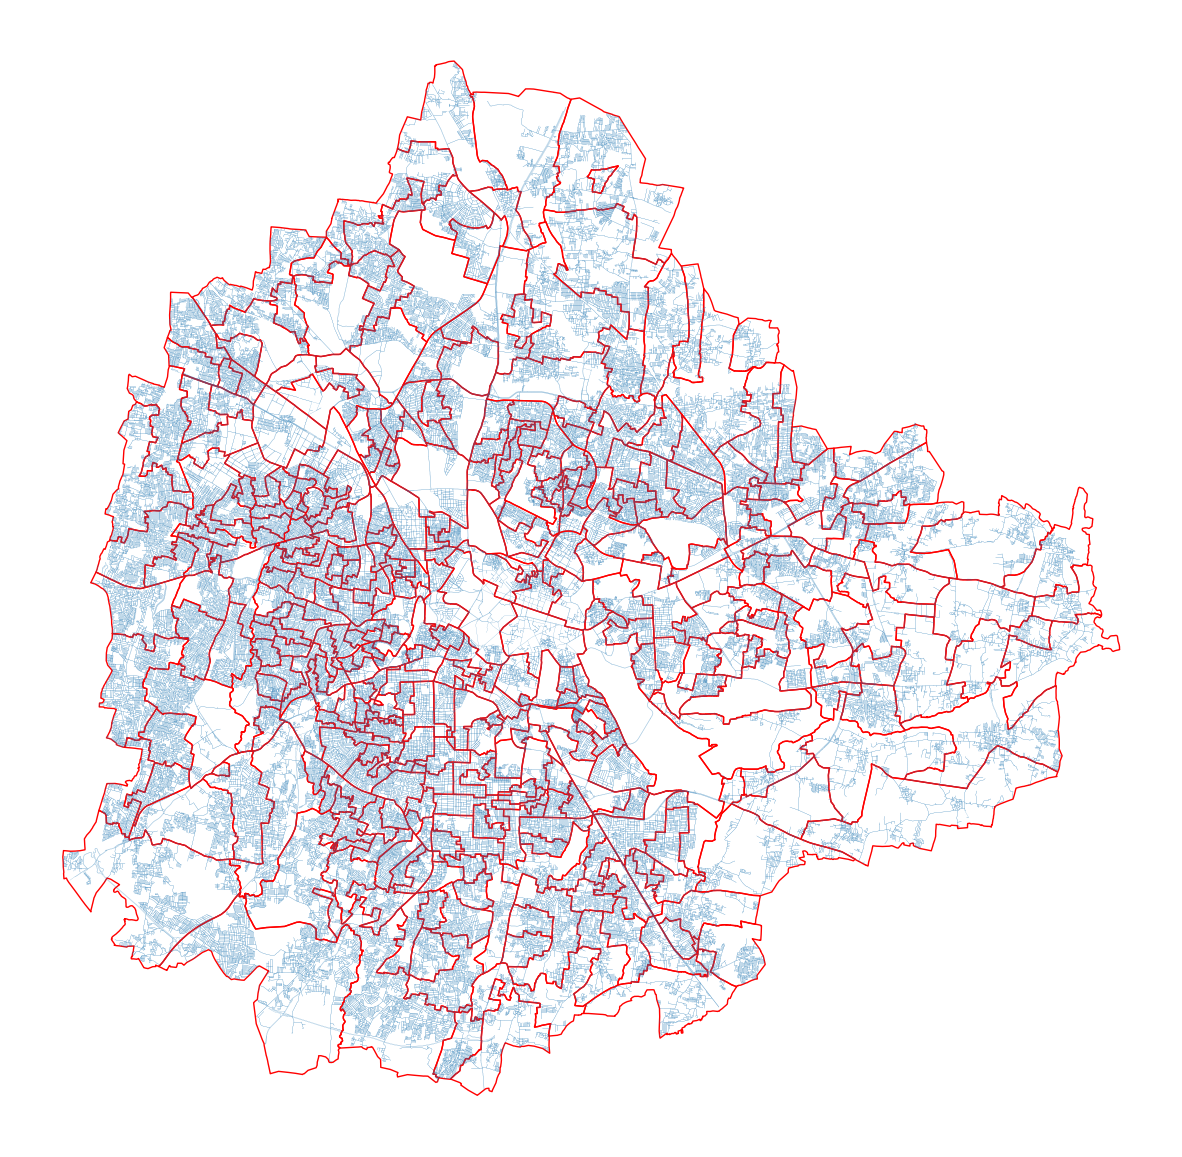

In [24]:
fig_path = IMAGES_DIR / 'road_network_bang_with_wards_drive.png'
fig, ax = plt.subplots(1,1)
fig.set_size_inches(15,15)
edges.plot(linewidth = 0.1, ax = ax)
df.plot(ax = ax, facecolor="none", edgecolor="red")
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

## Statistics

Before proceeding, we need to reproject the file. In order to compute statistics etc., we cannot use files in latitude and longitude as a lot of computations are in metres. OSMNX has a built-in function to just convert this and projects this to the local UTM (which is UTM CRS 32643) for Bangalore. 

In [25]:
# https://github.com/gboeing/tec-workshop/blob/main/workshop1.ipynb
G_proj = ox.projection.project_graph(G)
print(f'The coordinate are now in {G_proj.graph["crs"]}')

The coordinate are now in EPSG:32643


In [26]:
stats = ox.basic_stats(G_proj)
stats

{'n': 154529,
 'm': 392462,
 'k_avg': 5.079460813180697,
 'edge_length_total': 24218873.06462919,
 'edge_length_avg': 61.710109678463624,
 'streets_per_node_avg': 2.649237359977739,
 'streets_per_node_counts': {0: 0,
  1: 37611,
  2: 131,
  3: 95774,
  4: 20880,
  5: 129,
  6: 4},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.2433912081227472,
  2: 0.0008477373179144367,
  3: 0.6197801059995212,
  4: 0.13512026868743085,
  5: 0.0008347947634424606,
  6: 2.588510894395227e-05},
 'intersection_count': 116918,
 'street_length_total': 12961724.101581167,
 'street_segment_count': 204429,
 'street_length_avg': 63.40452725191224,
 'circuity_avg': 1.03140261319673,
 'self_loop_proportion': 0.00028860875903125293}

In [27]:
print(f'The street length is {stats["street_length_total"]:.2f} metres or {stats["street_length_total"]/1000:.2f} km.') 

The street length is 12961724.10 metres or 12961.72 km.


Compute the area for Bangalore:

In [28]:
## https://github.com/gboeing/osmnx-examples/blob/main/notebooks/
## 06-stats-indicators-centrality.ipynb
area = ox.projection.project_gdf(df).union_all().area
print(area)

717209573.3626949


In [29]:
print(f'The total area of Bangalore is {area/1000000:.2f} km2')

The total area of Bangalore is 717.21 km2


With the area as a parameter, you can obtain even more statistics:

In [30]:
stats_area = ox.basic_stats(G_proj, area=area)

In [31]:
stats_area

{'n': 154529,
 'm': 392462,
 'k_avg': 5.079460813180697,
 'edge_length_total': 24218873.06462919,
 'edge_length_avg': 61.710109678463624,
 'streets_per_node_avg': 2.649237359977739,
 'streets_per_node_counts': {0: 0,
  1: 37611,
  2: 131,
  3: 95774,
  4: 20880,
  5: 129,
  6: 4},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.2433912081227472,
  2: 0.0008477373179144367,
  3: 0.6197801059995212,
  4: 0.13512026868743085,
  5: 0.0008347947634424606,
  6: 2.588510894395227e-05},
 'intersection_count': 116918,
 'street_length_total': 12961724.101581167,
 'street_segment_count': 204429,
 'street_length_avg': 63.40452725191224,
 'circuity_avg': 1.03140261319673,
 'self_loop_proportion': 0.00028860875903125293,
 'node_density_km': 215.45864101545428,
 'intersection_density_km': 163.0179020782176,
 'edge_density_km': 33768.19546771671,
 'street_density_km': 18072.435983821408}

In [32]:
print(f'The street density is {stats_area["street_density_km"]:.2f} metres per km squared or {stats_area["street_density_km"]/1000:.2f} km per square kilometer.') 

The street density is 18072.44 metres per km squared or 18.07 km per square kilometer.


## References

Boeing, G. (2025).  Modeling and Analyzing Urban Networks and Amenities With OSMnx. Geographical Analysis 57, no. 4: 567577. https://doi.org/10.1111/gean.70009.

https://github.com/gboeing/osmnx-examples/tree/f6e821f598ccdb659999d008429cf867c69dcda1/notebooks
